### 1) Chargement et aperçu du dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement des fichiers sans header
train = pd.read_csv("train.csv", header=None,sep=",", names=["label", "title", "text"])
test = pd.read_csv("test.csv", header=None, names=["label", "title", "text"])

In [123]:
# Premier aperçu des données
pd.set_option('display.max_colwidth', None)
display(train.head())

# Nombre de lignes
print ("Shape de train.csv : ",train.shape,'\n')
print ("Shape de test.csv : ",test.shape)

,label,title,text
0,2,Stuning even for the non-gamer,This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^
1,2,The best soundtrack ever to anything.,"I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The music is timeless and I'm been listening to it for years now and its beauty simply refuses to fade.The price tag on this is pretty staggering I must say, but if you are going to buy any cd for this much money, this is the only one that I feel would be worth every penny."
2,2,Amazing!,"This soundtrack is my favorite music of all time, hands down. The intense sadness of ""Prisoners of Fate"" (which means all the more if you've played the game) and the hope in ""A Distant Promise"" and ""Girl who Stole the Star"" have been an important inspiration to me personally throughout my teen years. The higher energy tracks like ""Chrono Cross ~ Time's Scar~"", ""Time of the Dreamwatch"", and ""Chronomantique"" (indefinably remeniscent of Chrono Trigger) are all absolutely superb as well.This soundtrack is amazing music, probably the best of this composer's work (I haven't heard the Xenogears soundtrack, so I can't say for sure), and even if you've never played the game, it would be worth twice the price to buy it.I wish I could give it 6 stars."
3,2,Excellent Soundtrack,"I truly like this soundtrack and I enjoy video game music. I have played this game and most of the music on here I enjoy and it's truly relaxing and peaceful.On disk one. my favorites are Scars Of Time, Between Life and Death, Forest Of Illusion, Fortress of Ancient Dragons, Lost Fragment, and Drowned Valley.Disk Two: The Draggons, Galdorb - Home, Chronomantique, Prisoners of Fate, Gale, and my girlfriend likes ZelbessDisk Three: The best of the three. Garden Of God, Chronopolis, Fates, Jellyfish sea, Burning Orphange, Dragon's Prayer, Tower Of Stars, Dragon God, and Radical Dreamers - Unstealable Jewel.Overall, this is a excellent soundtrack and should be brought by those that like video game music.Xander Cross"
4,2,"Remember, Pull Your Jaw Off The Floor After Hearing it","If you've played the game, you know how divine the music is! Every single song tells a story of the game, it's that good! The greatest songs are without a doubt, Chrono Cross: Time's Scar, Magical Dreamers: The Wind, The Stars, and the Sea and Radical Dreamers: Unstolen Jewel. (Translation varies) This music is perfect if you ask me, the best it can be. Yasunori Mitsuda just poured his heart on and wrote it down on paper."


Shape de train.csv :  (3600000, 3) 

Shape de test.csv :  (400000, 3)


In [32]:
# Types des colonnes
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3600000 entries, 0 to 3599999
Data columns (total 3 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   label   int64 
 1   title   object
 2   text    object
dtypes: int64(1), object(2)
memory usage: 82.4+ MB


In [33]:
# Valeurs manquantes
train.isna().sum()

label      0
title    207
text       0
dtype: int64

il y a quasiment systématiquement un titre qui accompagne la review. Donc on aura intérêt dans le pre processing à concaténer le titre avec la review pour récupérer l'information contenue dans le titre.

In [34]:
# Analyse des doublons pour les reviews
print("Nombre de review en double :", int(train.duplicated(subset=["text"]).sum()))

Nombre de review en double : 5217


Sur 3 600 000 reviews, cela représente 0,14% (à supprimer lors du pre processing)

###  2) Analyse univariée

In [128]:
# Replace des valeurs 1 et 2 par "positif" et "negatif"
label_map = {1: "negative", 2: "positive"}
train["sentiment"] = train["label"].map(label_map)

c:\temp\ipykernel_17568\1050378594.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


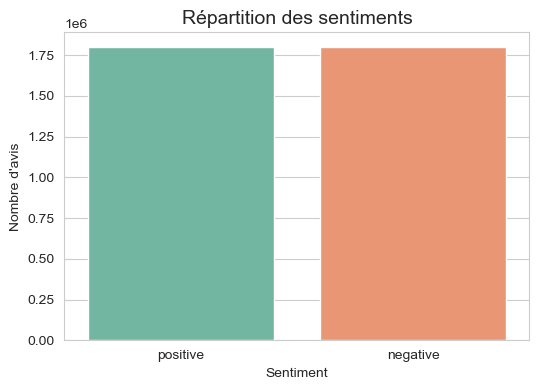

In [36]:
# distribution des classes (positif / negatif)
train["label"].value_counts()


plt.figure(figsize=(6,4))
sns.countplot(
    x=train["sentiment"],
    palette="Set2"
)
plt.title("Répartition des sentiments", fontsize=14)
plt.xlabel("Sentiment")
plt.ylabel("Nombre d'avis")
plt.show()

In [37]:
# Longueur des reviews
train["text_length"] = train["text"].str.len()
train["text_length"].describe()

count    3.600000e+06
mean     4.051396e+02
std      2.342711e+02
min      4.000000e+00
25%      2.070000e+02
50%      3.560000e+02
75%      5.660000e+02
max      1.010000e+03
Name: text_length, dtype: float64

* count = 3 600 000 reviews
* mean ≈ 405 caractères
* std ≈ 234
* min = 4
* 25% = 207
* 50% (médiane) = 356
* 75% = 566
* max ≈ 1000

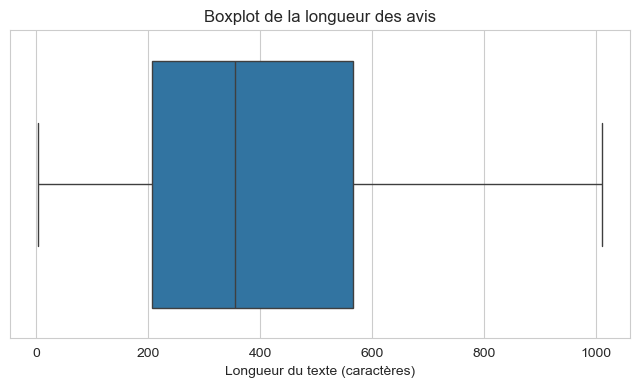

In [10]:
plt.figure(figsize=(8,4))
sns.boxplot(x=train["text_length"])
plt.title("Boxplot de la longueur des avis")
plt.xlabel("Longueur du texte (caractères)")
plt.show()

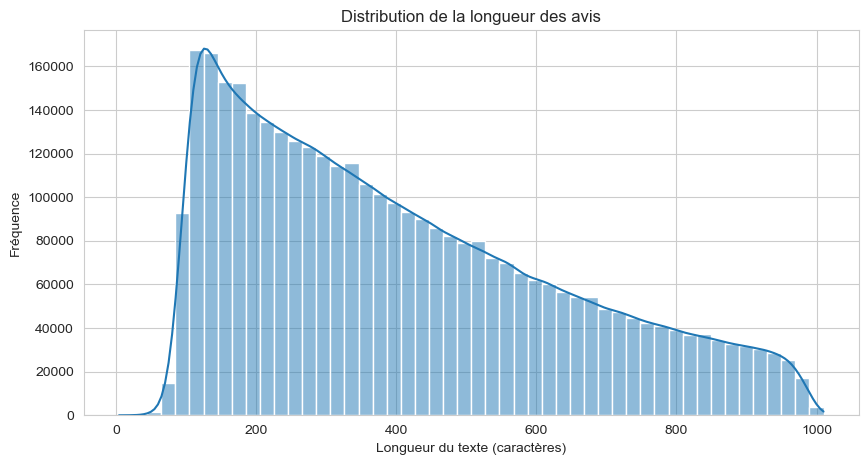

In [38]:
# Histogramme des longueurs des reviews
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(train["text_length"], bins=50, kde=True)
plt.title("Distribution de la longueur des avis")
plt.xlabel("Longueur du texte (caractères)")
plt.ylabel("Fréquence")
plt.show()

c:\temp\ipykernel_17568\680356305.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


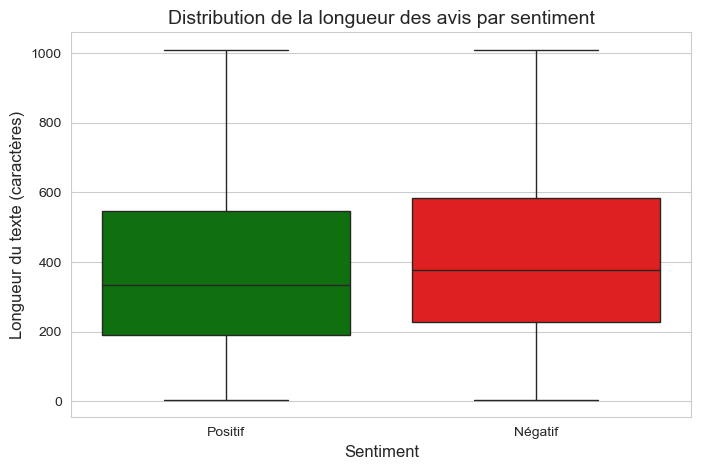

In [39]:
# Analyse de la longueur des reviews par sentiment

import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set_style("whitegrid")

# Remplacement des labels numériques par texte explicite
train["sentiment_label"] = train["label"].map({
    1: "Négatif",
    2: "Positif"
})

plt.figure(figsize=(8,5))

sns.boxplot(
    x=train["sentiment_label"],
    y=train["text_length"],
    palette={"Négatif": "red", "Positif": "green"}
)

plt.title("Distribution de la longueur des avis par sentiment", fontsize=14)
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Longueur du texte (caractères)", fontsize=12)

plt.show()

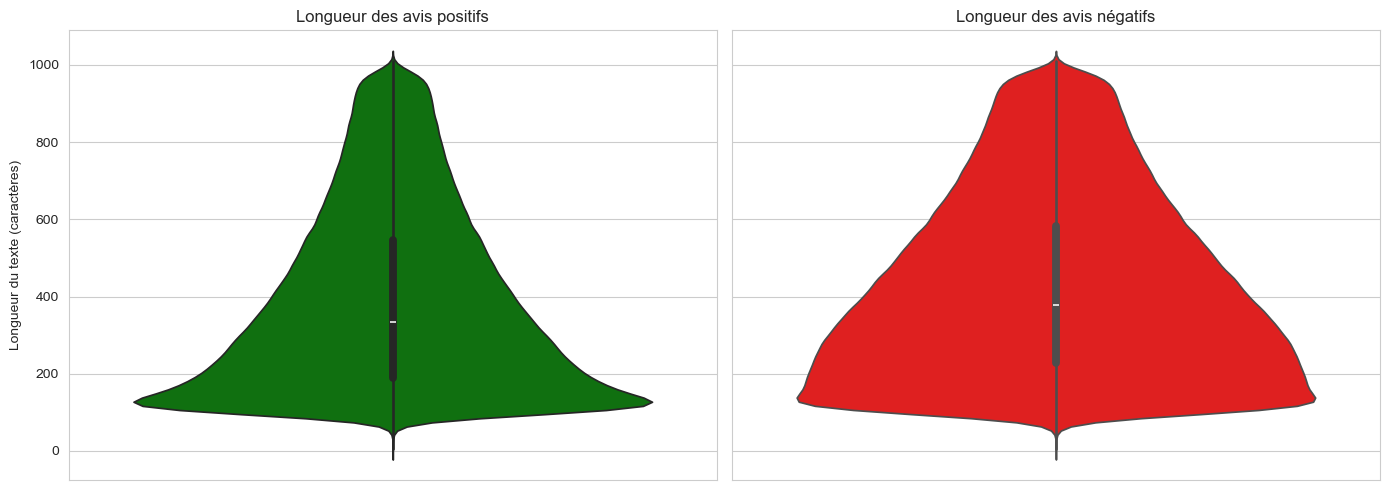

In [14]:
sns.set_style("whitegrid")

# Séparation des données
train_pos = train[train["label"] == 2]
train_neg = train[train["label"] == 1]

# Création des subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Violinplot POSITIFS
sns.violinplot(
    ax=axes[0],
    y=train_pos["text_length"],
    color="green"
)
axes[0].set_title("Longueur des avis positifs")
axes[0].set_xlabel("")
axes[0].set_ylabel("Longueur du texte (caractères)")

# Violinplot NEGATIFS
sns.violinplot(
    ax=axes[1],
    y=train_neg["text_length"],
    color="red"
)
axes[1].set_title("Longueur des avis négatifs")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

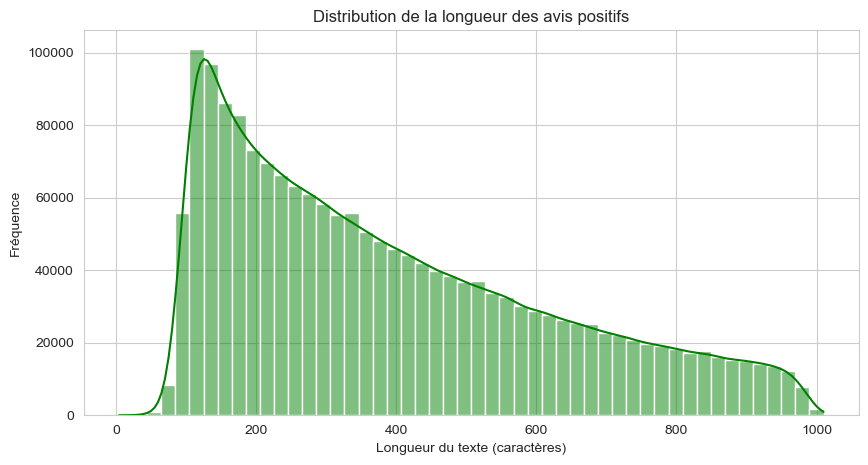

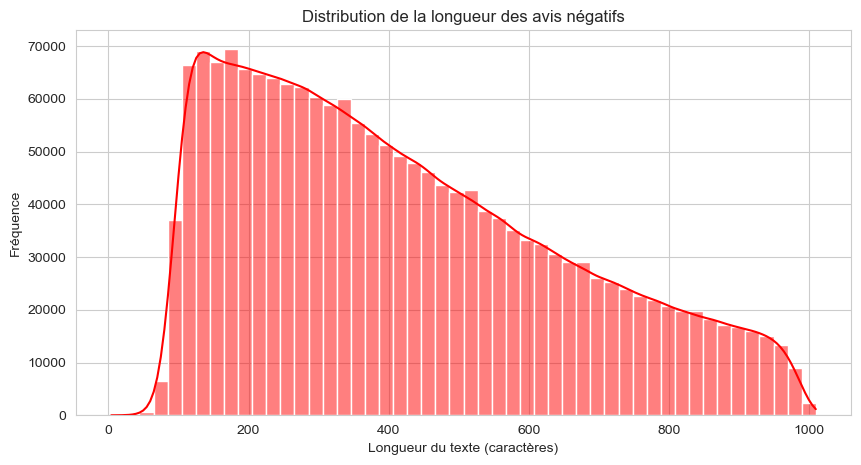

In [13]:
sns.set_style("whitegrid")

# Séparation des données
train_pos = train[train["label"] == 2]
train_neg = train[train["label"] == 1]

# Histogramme POSITIFS
plt.figure(figsize=(10,5))
sns.histplot(train_pos["text_length"], bins=50, kde=True, color="green")
plt.title("Distribution de la longueur des avis positifs")
plt.xlabel("Longueur du texte (caractères)")
plt.ylabel("Fréquence")
plt.show()

# Histogramme NEGATIFS
plt.figure(figsize=(10,5))
sns.histplot(train_neg["text_length"], bins=50, kde=True, color="red")
plt.title("Distribution de la longueur des avis négatifs")
plt.xlabel("Longueur du texte (caractères)")
plt.ylabel("Fréquence")
plt.show()

## 5	Analyse qualité du texte

In [ ]:
# Détection du contenu html

import re

# Liste de balises HTML reconnues
HTML_TAGS = [
    "a","b","i","u","p","br","hr","div","span","strong","em","img",
    "table","tr","td","th","ul","ol","li","body","head","html","title"
]

html_pattern = re.compile(r"</?(" + "|".join(HTML_TAGS) + r")( [^>]+)?>", re.IGNORECASE)

def contains_html(text):
    return bool(html_pattern.search(text))

train["has_html"] = train["text"].apply(contains_html)

print("Nombre de reviews contenant de vraies balises HTML :", train["has_html"].sum(),"\n")

full_text = train[train["has_html"]]["text"].iloc[4]
print(full_text)

Nombre de reviews contenant de vraies balises HTML : 395 

I started to read just the introduction and I started to sense that something was wrong, very wrong. Besides the assumption of eco-feminism as compatible with Orthodoxy, he discusses the occult he was deeply involved with in terms that made me more than uncomfortable: admiration, an ambassador's tone in describing occult matters, almost reminiscent of patriotism. This is the sort of thing one should speak of out of deep humility spurred by repentance from serious sin.This is the first time I have purchased a book that I thought was Orthodox theology and didn't get past the introduction before regretting I'd made the purchase.If you wonder, "Does this critic have anything better to say?" then <a href="http://www.amazon.com/author/cjshayward">I invite you to visit my own author's section.</a>


In [77]:
# Détection des caractères non ASCII
# Ce code parcourt chaque caractère (ord(c) > 127 = non ASCII)

def contains_visible_non_ascii(text):
    return any(ord(c) > 127 and c.isprintable() for c in text)

visible_non_ascii_df = train[train["text"].apply(contains_visible_non_ascii)]

print("Nombre de reviews avec des caractères non ASCII visibles :", len(visible_non_ascii_df))
print(visible_non_ascii_df["text"].iloc[0])

Nombre de reviews avec des caractères non ASCII visibles : 11728
LO QUE PENSE QUE NO ME INTERESABA SABER SOBRE EL BOX Y SUS CAMPEONES...PERO ME CAUTIVO Y LO LEI HASTA EL FINAL !AHORA SI PUEDO DISCUTIR DE BOX CON MI ESPOSO Y MIS CUÑADOS...¡Y HASTA CON MI SUEGRO, QUE ES EX BOXEADOR !


Le dataset peut contenir :

* des accents (é, ñ, ü)
* des tirets typographiques (–, —)
* des apostrophes “smart quotes” (“ ” ’)
* des emojis
* des caractères de formatage invisibles

11 728 reviews contenant au moins un caractère non ASCII = 0,32 % du dataset

Taux  normal pour des textes générés par des utilisateurs réels.

In [78]:
# Détection de ponctuation suspecte = ponctuation répétée ("!!!", "???", "..", "!!!!", etc.)
import re

def contains_weird_punct(text):
    return bool(re.search(r"([!?\.])\1{2,}", text))

train["weird_punct"] = train["text"].apply(contains_weird_punct)

print("Nombre de reviews avec ponctuations suspectes :", int(train["weird_punct"].sum()))

# Afficher quelques reviews concernées
pd.set_option('display.max_colwidth', None)
examples = train[train["weird_punct"]].loc[124:125]
display(examples[["text"]])


Nombre de reviews avec ponctuations suspectes : 562550


,text
124,"This cereal is so sweet....yet so good for you! One taste=ADDICTION!!!! I just tried this cereal out of curiousity and I was hooked! It is an excellent breakfast choice, or just any time to eat! Especially as breakfast because you will crave more honey taste and you won't be hungry later {probably because of how much you'd eat} and it is actually sweeter and better than Honey Bunches of Oats. Cap'n Crunch Berries is an option, but this splendid cereal is SO FILLED WITH A HONEY-FILLED TASTE! I have not tried much better tasting cereal than this! Oh!"
125,"This cereal is great because it tastes so good. You just crave it. But a word of warning: read the label. Last time my husband and I looked, it had saturated fat! All the other cereals in our cabinet did not... hmmmm. Another reviewer noticed this problem too!Also, Amazon's price of $23 is outrageous. It is between $1.99 to $2.50 in our stores."


≈ 15,6 % du dataset
ce n’est pas du spam dans la majorité des cas : 
les utilisateurs expriment leurs émotions avec "..." “!!!” ou “????”
A ne pas supprimer : Ponctuation expressive = signal utile.


In [80]:
# Détection des reviews très courtes (≤ 3 mots)
train["word_count"] = train["text"].str.split().apply(len)

short_reviews = train[train["word_count"] <= 3]

print("Nombre de reviews très courtes (≤ 3 mots) :", short_reviews.shape[0], "\n")

# Afficher le texte complet sans être tronqué
pd.set_option('display.max_colwidth', None)

# Afficher les 10 premières reviews courtes
display(short_reviews[["text"]].head(10))

# Afficher une seule review pour lecture intégrale
print("\n--- Exemple de review très courte ---\n")
print(short_reviews["text"].iloc[0])

Nombre de reviews très courtes (≤ 3 mots) : 34 



,text
372567,Great Purchase CKVKLJ;JNVKZ;KCVJJVK'ZJXC'VKLZXVMK'ZLXMCV'ZLKCV'LKZMX'LKVCCVCVCVCVCVCVCVCVC
567147,TeTerriffic!Terriffic!Terriffic!Terriffic!Terriffic!Terriffic!Terriffic!Terriffic!Terriffic!Terriffic!Terriffic!Terriffic!
589388,drek
629878,...............................
759194,"Thisis.the.very.first.book.by.her.that.I.had.a.hard.time.getting.thru,however.I.will.continue.reading.her.because.all.the.pastread.were.very.good.she.is.one.of.my.favorite.authors."
817508,gogogogagagagagagamandiffheuejkuawieuajdsifjhjhjadhjfhjshuehfjcnjksbjkgfbqhjbhkkkjfbs---------s-u-t6
866882,threewolveseverhowlingmoonabovemocksme?birdin thedistancegreetsthecruelmorninglupusconsumesmyfeveredbrainiwearanextralarge
937431,//:practical//logikal//clear explanations//crazycool!
1059216,goooood
1373977,booooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooooo



--- Exemple de review très courte ---

Great Purchase CKVKLJ;JNVKZ;KCVJJVK'ZJXC'VKLZXVMK'ZLXMCV'ZLKCV'LKZMX'LKVCCVCVCVCVCVCVCVCVC


0,00094 % du dataset : sans impact sur un dataset de 3.6M avis mais on va les supprimer quand même car ils sont difficiles à analyser.Ce sont soit une suite de caractères sans sens, soit des mots concaténés (pas d'analyse possible)

In [81]:
# Détection des répétitions suspectes
'''
Objectif : détecter si certains avis contiennent :
- répétition du même mot 3+ fois d’affilée
- patterns robotisés (“buy buy buy”, “good good good”)
- spam mécanique
'''

def repeated_words(text):
    # Détecte des répétitions de 3 occurrences ou plus du même mot ("good good good")
    return bool(re.search(r"(\b\w+\b)(\s+\1){2,}", text, flags=re.IGNORECASE))

train["repeated_words"] = train["text"].apply(repeated_words)

print("Nombre de reviews avec répétitions suspectes :", int(train["repeated_words"].sum()), "\n")

# Pour afficher le texte complet sans troncature
pd.set_option('display.max_colwidth', None)

# Extraire les reviews concernées
rep_df = train[train["repeated_words"]]

# Afficher les 10 premières reviews répétitives
display(rep_df[["text"]].head(10))

# Afficher un exemple brut
print("\n--- Exemple de review avec répétitions suspectes ---\n")
print(rep_df["text"].iloc[0])

Nombre de reviews avec répétitions suspectes : 9979 



,text
93,"2 stars of 5 for this slow dull ""classical"" 1980's style movie. This movie has a young Jason Bateman in the lead. Very very very slow and dull with a few moments of bad 1980's style music. To our relief the background music (which is very annoying) is kept to a minimum. Though it attempts to be an action/suspense movie, it achieves neither. I'd suggest skipping this movie."
855,"typically, I will force myself to read even the worst books (for class, for ""fun"", because I think I should), but when I read this book for a [...] English course, I quickly realized it was one of the worst books ever (not to be taken lightly, seriously), certainly not worthy of a classic, boring, endless details that no one cares about... blah blah blah. Terrible. I was bored. It might have been too difficult for a 9th grader, but I wouldn't read it now either.on the other hand, my brother loved it."
878,"Yes, I am a 17 yr old high school kid. But I can tell good books from the bad ones. ""The Scarlet Letter"" is a ""classical"" tale of 2 lovers. To be concise, this novel is too wordy to be enjoyable. People can say it's a classic romantic novel, it has good character developments, it has good themes and ironies, blah blah blah. I, like most people, don't judge a book by checking out its trap metaphors; all in all leave this book to a ""Doctor of Puritanical Philosophy"". If youre looking for a more entertaining classic, read ""Huck Finn"" by Twain."
1070,A Charlie Brown Christmas. Does this REALLY need a review. Who doesn't love CB?? Whaa whaa whaa whhhaaaaaa. So glad I finally purchased this.
1312,"I wanted to read this book because the simple life of the Amish people intrigued me.I wish this lady would have talked more about the Amish.Instead,all you read about is ""Me,me,me"".""What am I doing in my life?""Why do I do this/that?"" blah blah blah.By the end of the book the reader really doesn't care anymore!It was scarey for me to find out that this woman is a therapist-YIKES!The reason I gave it 2 stars is that (1) When she does talk about the Amish it is interesting (2) It is a short book and a quick read."
1399,"many people give 5 stars in a rather nonchalant manner completly nulling the value of the prestigious 5. This cd is the most essential black metal album I've ever come across. I do not sheepishly just ""give"" the five star rating, I stand by my rating proudly for all to see. THIS IS THE ONE! EPIC! also I do not listen to garbage black metal like most so you can trust my opinion. This album drives a sword through the pu@#y a!@ bellies of all other pu%$y a#@ bands. HAH HAH HAHp.s. kill nevermore"
1489,"I am a huge fan of the Tomb Raider series, and have played all five other games on my PC. I love them. I was so excited to get this one, and sooooo disappointed with the quality. Glitchy glitchy glitchy. Do not buy this game. The controls are terrible. While all other 5 games play out smoothly, this one is slow, stalls, goes blank some times, and takes minutes to load to new chapters. Now I don't have a fancy schmancy computer, but I have been able to play all the other games on it just fine without any hitch. This is just crap. It makes me feel like I have to go buy a $2000 computer just to be able to play this $30 game! It probably runs better on a PS 2, so if you have one of those don't bother with the PC version. Thanks a lot Eidos, I totally wasted time and money and am warning future buyers to BEWARE!"
1627,"but man yeah yeah yeah its good and all that, but man, 9 dollars for three songs?! isn't that like an oxymoron?"
1747,I couldn't. The quality of this DVD is horrible! It was like watching an old old old VHS tape. I'm not surprised it was so cheap but I'm shocked that it was rated 4 and a half stars when I bought it. I was taken for a ride and it wasn't on the back of a horse.
1972,The material is thin thin thin which I expected from this kind of costume. The mask didn't really hold up for one halloween party and one 


--- Exemple de review avec répétitions suspectes ---

2 stars of 5 for this slow dull "classical" 1980's style movie. This movie has a young Jason Bateman in the lead. Very very very slow and dull with a few moments of bad 1980's style music. To our relief the background music (which is very annoying) is kept to a minimum. Though it attempts to be an action/suspense movie, it achieves neither. I'd suggest skipping this movie.


0,24 % du dataset
proportion faible mais significative

In [82]:
# Synthèse de la partie 5 :
summary = {
    "HTML tags": int(train["has_html"].sum()),
    "Non-ASCII chars": int(train["non_ascii"].sum()),
    "Weird punctuation": int(train["weird_punct"].sum()),
    "Repeated words": int(train["repeated_words"].sum()),
    "Short reviews (<=3 words)": int(train[train["word_count"] <= 3].shape[0])
}

summary

{'HTML tags': 395,
 'Non-ASCII chars': 11728,
 'Weird punctuation': 562550,
 'Repeated words': 9979,
 'Short reviews (<=3 words)': 34}

## 6) Analyse textuelle exploratoire

In [2]:
# Nettoyage minimal 

import re

def clean_text_simple(text):
    # minuscules
    text = text.lower()
    # suppression de la ponctuation simple / caractères non alphabétiques
    text = re.sub(r"[^a-z\s']", " ", text)
    # normalisation des espaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Application du nettoyage minimal
train["clean_text"] = train["text"].apply(clean_text_simple)

In [84]:
# vérification du résultat sur quelques lignes
# Affichage complet des colonnes texte
pd.set_option('display.max_colwidth', None)

# Vérification du résultat sur quelques lignes
train[["text", "clean_text"]].head(5)

,text,clean_text
0,This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^,this sound track was beautiful it paints the senery in your mind so well i would recomend it even to people who hate vid game music i have played the game chrono cross but out of all of the games i have ever played it has the best music it backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras it would impress anyone who cares to listen
1,"I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The music is timeless and I'm been listening to it for years now and its beauty simply refuses to fade.The price tag on this is pretty staggering I must say, but if you are going to buy any cd for this much money, this is the only one that I feel would be worth every penny.",i'm reading a lot of reviews saying that this is the best 'game soundtrack' and i figured that i'd write a review to disagree a bit this in my opinino is yasunori mitsuda's ultimate masterpiece the music is timeless and i'm been listening to it for years now and its beauty simply refuses to fade the price tag on this is pretty staggering i must say but if you are going to buy any cd for this much money this is the only one that i feel would be worth every penny
2,"This soundtrack is my favorite music of all time, hands down. The intense sadness of ""Prisoners of Fate"" (which means all the more if you've played the game) and the hope in ""A Distant Promise"" and ""Girl who Stole the Star"" have been an important inspiration to me personally throughout my teen years. The higher energy tracks like ""Chrono Cross ~ Time's Scar~"", ""Time of the Dreamwatch"", and ""Chronomantique"" (indefinably remeniscent of Chrono Trigger) are all absolutely superb as well.This soundtrack is amazing music, probably the best of this composer's work (I haven't heard the Xenogears soundtrack, so I can't say for sure), and even if you've never played the game, it would be worth twice the price to buy it.I wish I could give it 6 stars.",this soundtrack is my favorite music of all time hands down the intense sadness of prisoners of fate which means all the more if you've played the game and the hope in a distant promise and girl who stole the star have been an important inspiration to me personally throughout my teen years the higher energy tracks like chrono cross time's scar time of the dreamwatch and chronomantique indefinably remeniscent of chrono trigger are all absolutely superb as well this soundtrack is amazing music probably the best of this composer's work i haven't heard the xenogears soundtrack so i can't say for sure and even if you've never played the game it would be worth twice the price to buy it i wish i could give it stars
3,"I truly like this soundtrack and I enjoy video game music. I have played this game and most of the music on here I enjoy and it's truly relaxing and peaceful.On disk one. my favorites are Scars Of Time, Between Life and Death, Forest Of Illusion, Fortress of Ancient Dragons, Lost Fragment, and Drowned Valley.Disk Two: The Draggons, Galdorb - Home, Chronomantique, Prisoners of Fate, Gale, and my girlfriend likes ZelbessDisk Three: The best of the three. Garden Of God, Chronopolis, Fates, Jellyfish sea, Burning Orphange, Dragon's Prayer, Tower Of Stars, Dragon God, and Radical Dreamers - Unstealable Jewel.Overall, this is a excellent soundtrack and should be brought by those that like video game music.Xander Cross",i truly like this soundtrack and i enjoy video ga

c:\temp\ipykernel_10740\112797592.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


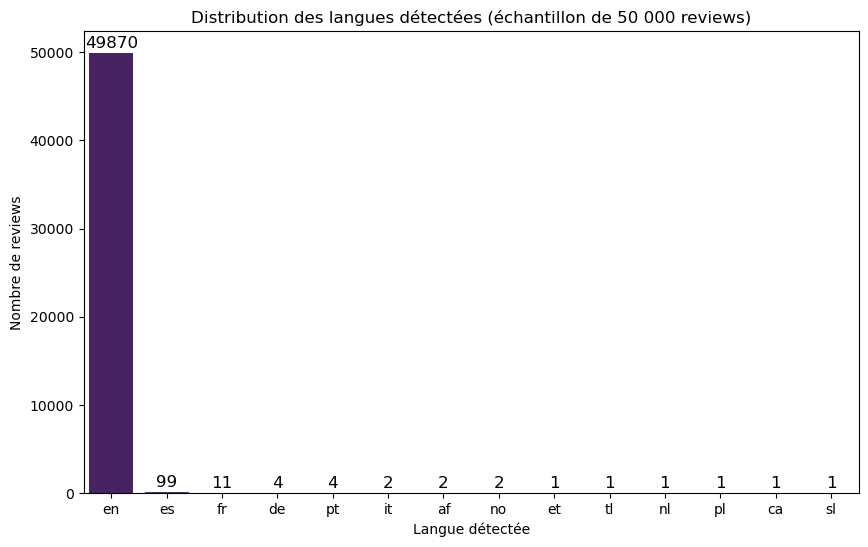

In [3]:
# Détection des langues présentes (Anglais / Français / Espagnol ....)

from langdetect import detect, DetectorFactory
DetectorFactory.seed = 42

# Échantillon équilibré
sample_lang = train.groupby("label").sample(25000, random_state=42)
sample_lang.shape

# Fonction de détection de langue
def detect_lang(text):
    try:
        return detect(text)
    except:
        return "unknown"

# Application de la détection
sample_lang["lang"] = sample_lang["clean_text"].apply(detect_lang)
sample_lang["lang"].value_counts()

# Barplot du nombre d’avis par langue
plt.figure(figsize=(10,6))
ax = sns.barplot(
    x=sample_lang["lang"].value_counts().index,
    y=sample_lang["lang"].value_counts().values,
    palette="viridis"
)

# Ajouter les valeurs sur les barres
for i, value in enumerate(sample_lang["lang"].value_counts().values):
    ax.text(i, value + 300, str(value), ha='center', va='bottom', fontsize=12)

plt.title("Distribution des langues détectées (échantillon de 50 000 reviews)")
plt.xlabel("Langue détectée")
plt.ylabel("Nombre de reviews")
plt.show()


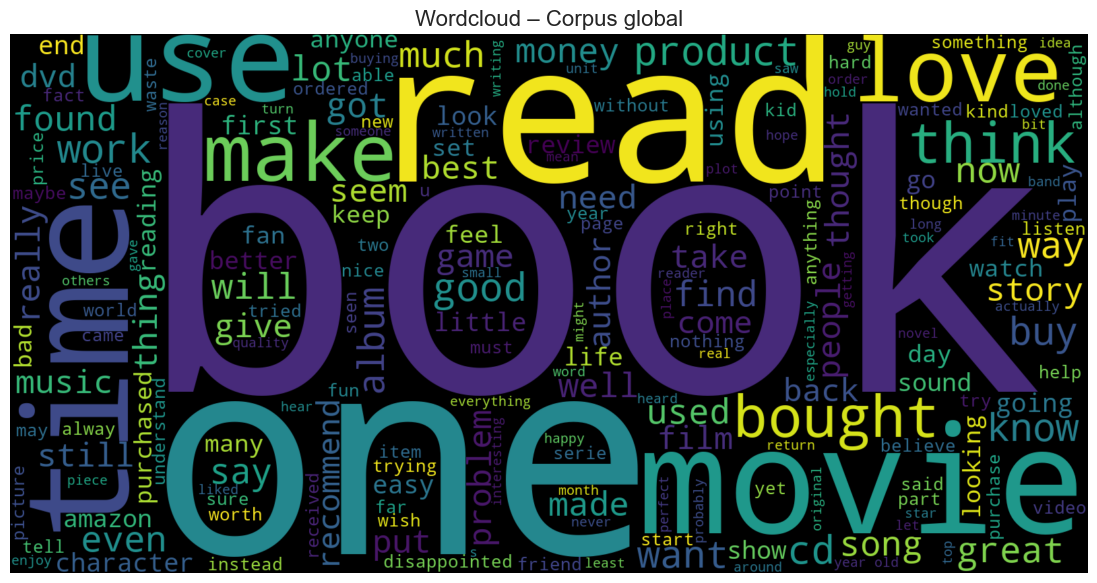

In [105]:
# Wordclouds

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Texte global
#text_all = " ".join(train["clean_text"])

# remplacer train par un échantillon de 1 million de lignes
sample = train.sample(1000000, random_state=42)
text_all = " ".join(sample["clean_text"])

wc_all = WordCloud(
    width=1600,
    height=800,
    background_color="black",
    colormap="viridis"
).generate(text_all)

plt.figure(figsize=(14,7))
plt.imshow(wc_all, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud – Corpus global", fontsize=16)
plt.show()

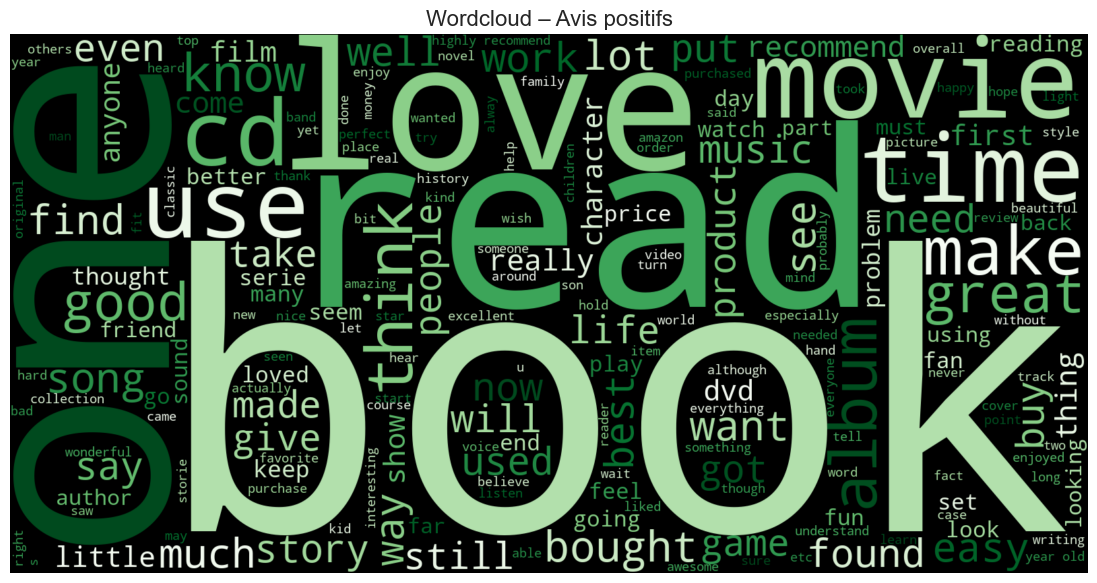

In [106]:
# Wordcloud positif
text_pos = " ".join(train[train["sentiment"] == "positive"]["clean_text"].sample(1000000, random_state=42))

wc_pos = WordCloud(
    width=1600,
    height=800,
    background_color="black",
    colormap="Greens"
).generate(text_pos)

plt.figure(figsize=(14,7))
plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud – Avis positifs", fontsize=16)
plt.show()

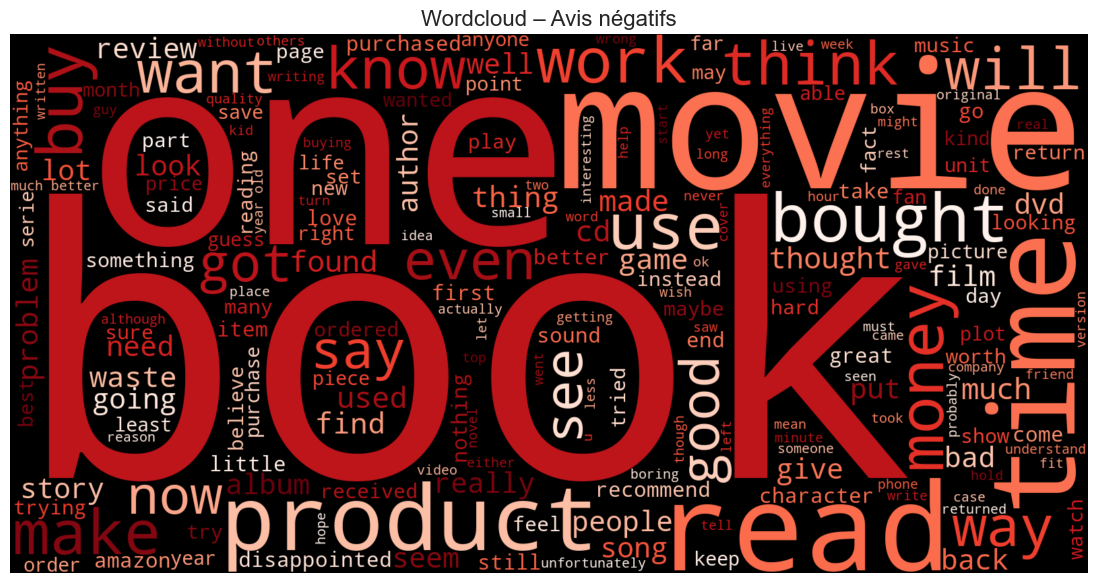

In [108]:
# Wordcloud négatif
text_neg = " ".join(train[train["sentiment"] == "negative"]["clean_text"].sample(1000000, random_state=42))

wc_neg = WordCloud(
    width=1600,
    height=800,
    background_color="black",
    colormap="Reds"
).generate(text_neg)

plt.figure(figsize=(14,7))
plt.imshow(wc_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud – Avis négatifs", fontsize=16)
plt.show()

In [109]:
# Fréquence des mots (sans stopwords)
'''
Objectif :
identifier les mots “à forte valeur informative”
comprendre les patterns lexicaux dominants
préparer la future vectorisation TF-IDF

On va extraire :

les top 20 mots du corpus
les top 20 mots positifs
les top 20 mots négatifs
'''


# charger les stopwords anglais
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop = set(stopwords.words("english"))


# Extraction des top words
from collections import Counter

def get_top_words(texts, n=20):
    tokens = []
    for t in texts:
        for w in t.split():
            if w not in stop:
                tokens.append(w)
    return Counter(tokens).most_common(n)



[nltk_data] Downloading package stopwords to
[nltk_data]     D:\Users\utheza\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [111]:
sample = train.sample(1000000, random_state=42)
top_global = get_top_words(sample["clean_text"])
top_pos = get_top_words(sample[sample["sentiment"]=="positive"]["clean_text"])
top_neg = get_top_words(sample[sample["sentiment"]=="negative"]["clean_text"])


c:\temp\ipykernel_17568\1948610912.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


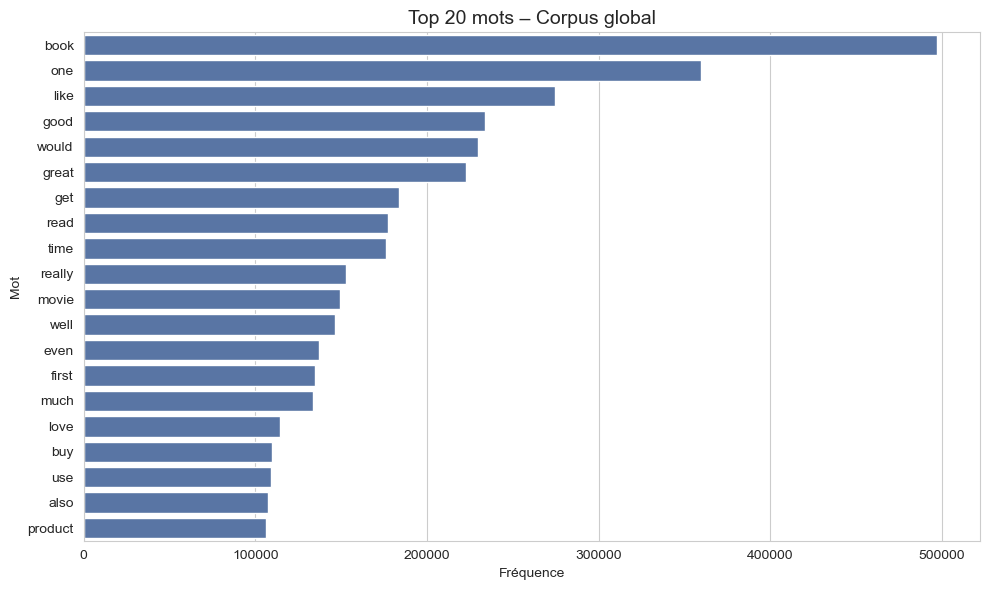

c:\temp\ipykernel_17568\1948610912.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


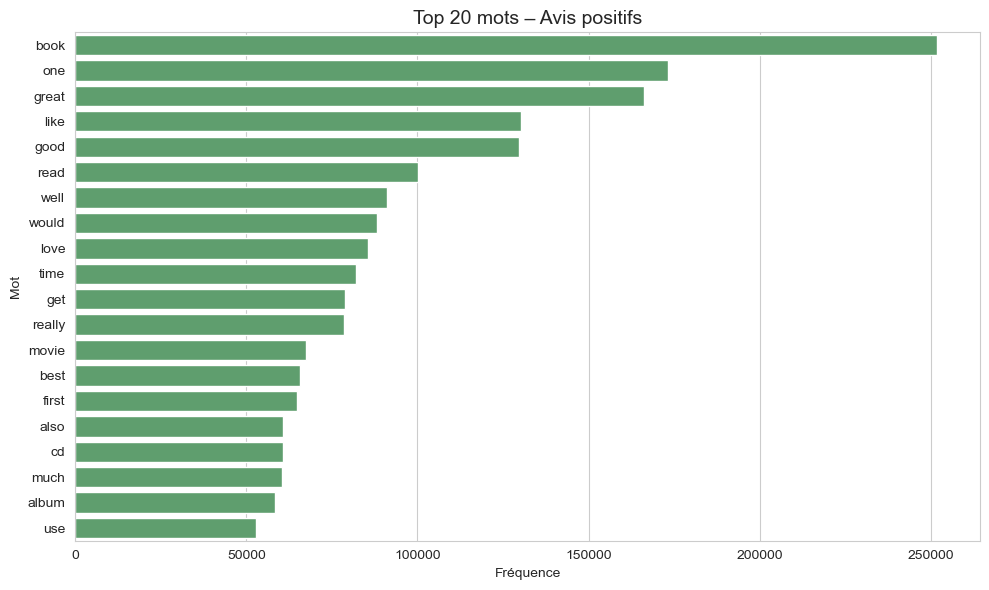

c:\temp\ipykernel_17568\1948610912.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


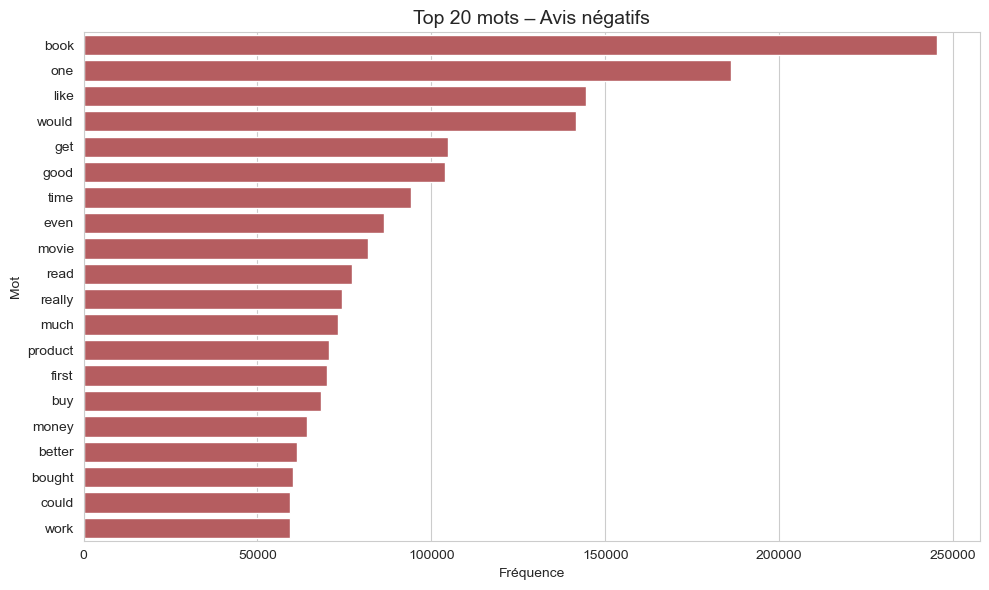

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

def plot_top_words(top_list, title, color):
    df = pd.DataFrame(top_list, columns=["word", "count"])

    plt.figure(figsize=(10,6))
    sns.barplot(
        data=df,
        x="count",
        y="word",
        palette=[color]*len(df)   # couleur uniforme
    )
    
    plt.title(title, fontsize=14)
    plt.xlabel("Fréquence")
    plt.ylabel("Mot")
    plt.tight_layout()
    plt.show()


# === Global ===
plot_top_words(top_global, "Top 20 mots – Corpus global", "#4C72B0")   # bleu

# === Positifs ===
plot_top_words(top_pos, "Top 20 mots – Avis positifs", "#55A868")      # vert

# === Négatifs ===
plot_top_words(top_neg, "Top 20 mots – Avis négatifs", "#C44E52")      # rouge

6.4	N-grams

c:\temp\ipykernel_17568\2213101287.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


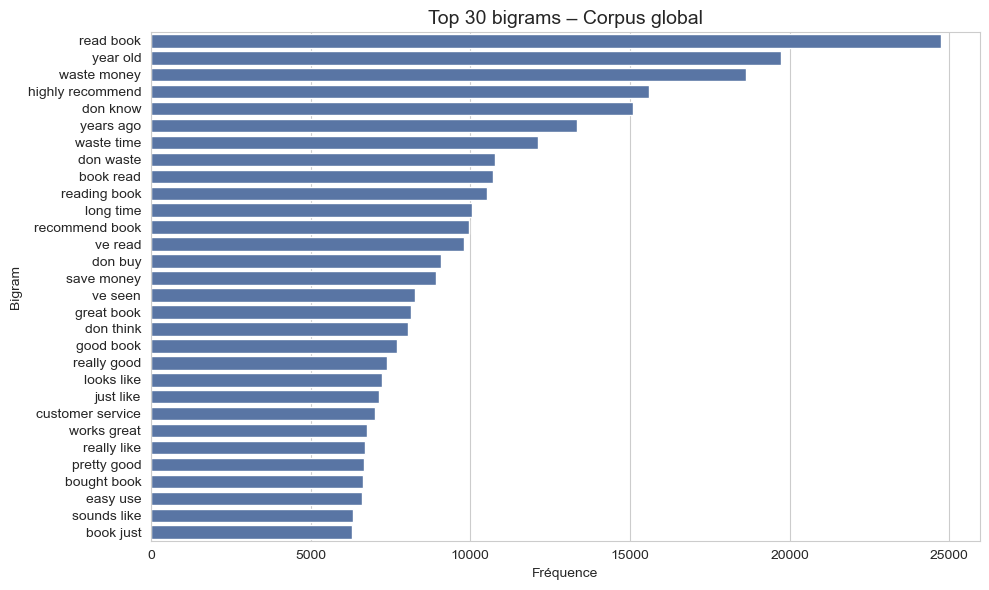

c:\temp\ipykernel_17568\2213101287.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


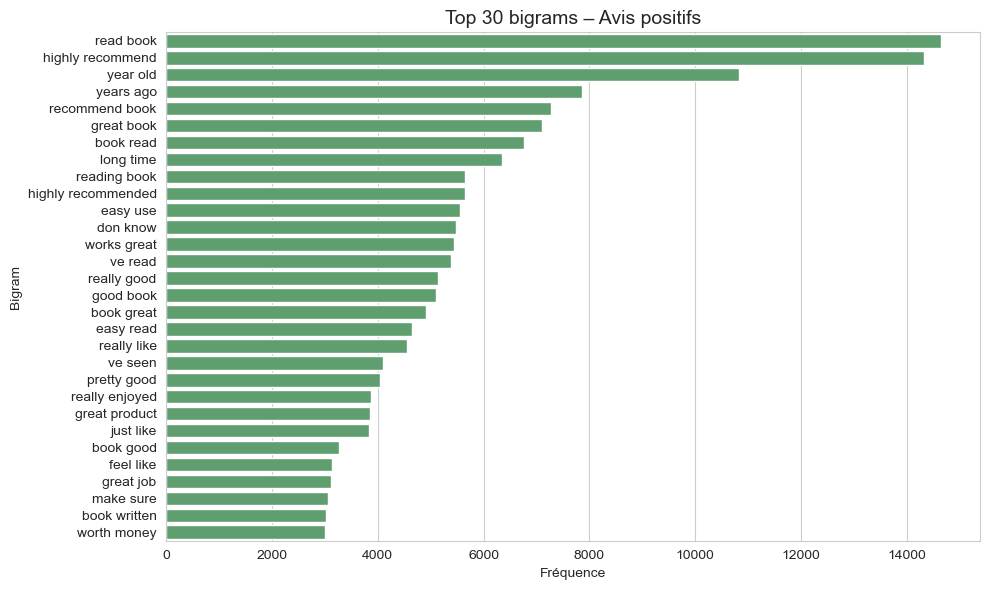

c:\temp\ipykernel_17568\2213101287.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


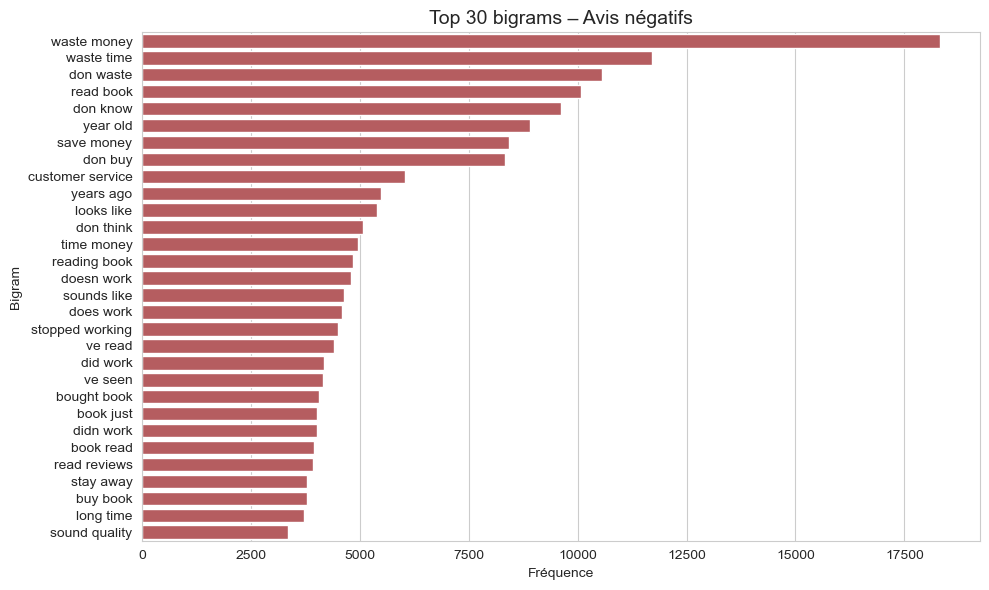

In [115]:
# Bigrams

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

sns.set_style("whitegrid")

def get_top_bigrams(texts, title, color):
    # Vectorisation bigrams
    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=(2, 2),
        max_features=30
    )
    X = vectorizer.fit_transform(texts)
    bigrams = vectorizer.get_feature_names_out()
    counts = X.sum(axis=0).A1  # fréquences

    df = pd.DataFrame({"bigram": bigrams, "count": counts})
    df = df.sort_values("count", ascending=False)

    # Plot horizontal
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=df,
        x="count",
        y="bigram",
        palette=[color] * len(df)
    )
    plt.title(title, fontsize=14)
    plt.xlabel("Fréquence")
    plt.ylabel("Bigram")
    plt.tight_layout()
    plt.show()

    return df


# === Global ===
bigrams_global_df = get_top_bigrams(
    sample["clean_text"],
    "Top 30 bigrams – Corpus global",
    "#4C72B0"
)

# === Positifs ===
bigrams_pos_df = get_top_bigrams(
    sample[sample["sentiment"]=="positive"]["clean_text"],
    "Top 30 bigrams – Avis positifs",
    "#55A868"
)

# === Négatifs ===
bigrams_neg_df = get_top_bigrams(
    sample[sample["sentiment"]=="negative"]["clean_text"],
    "Top 30 bigrams – Avis négatifs",
    "#C44E52"
)

c:\temp\ipykernel_22900\3155423680.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


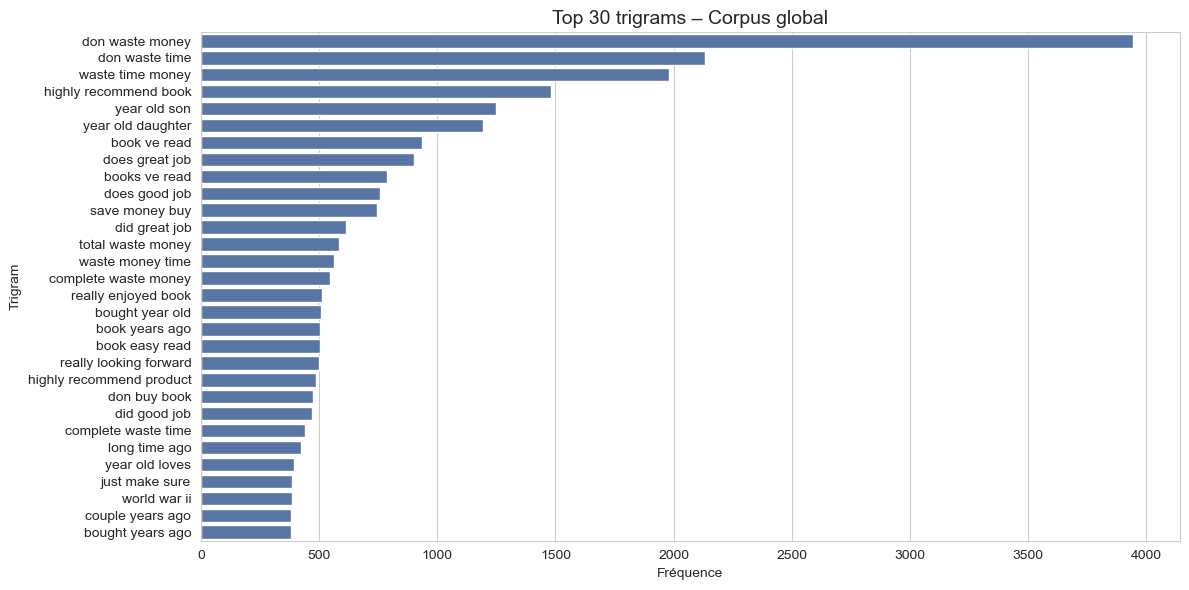

c:\temp\ipykernel_22900\3155423680.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


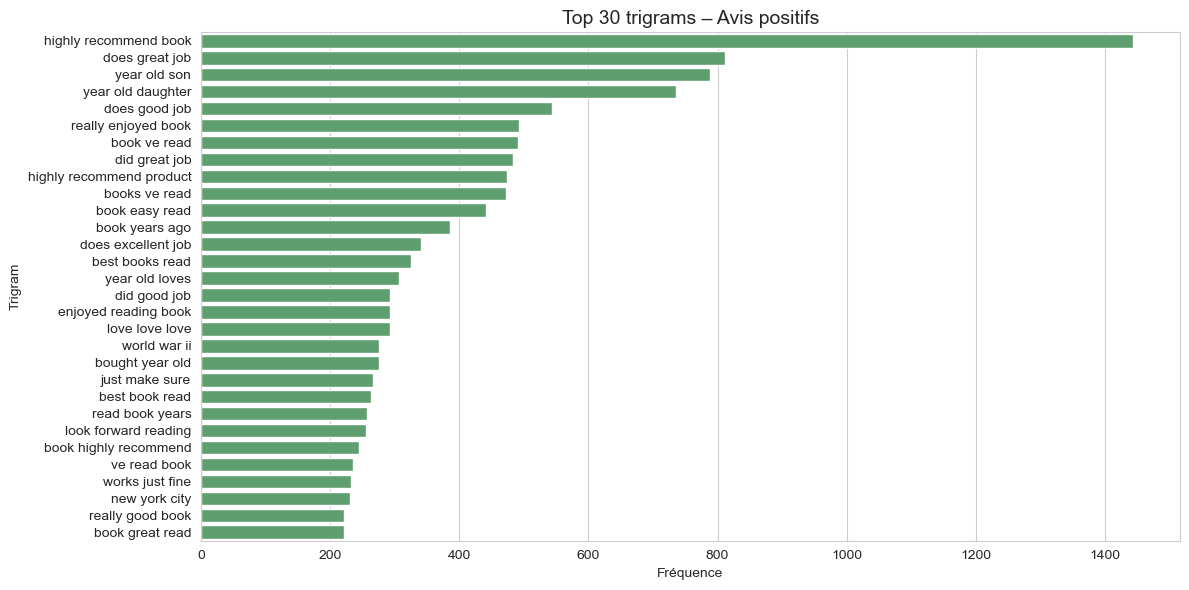

c:\temp\ipykernel_22900\3155423680.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


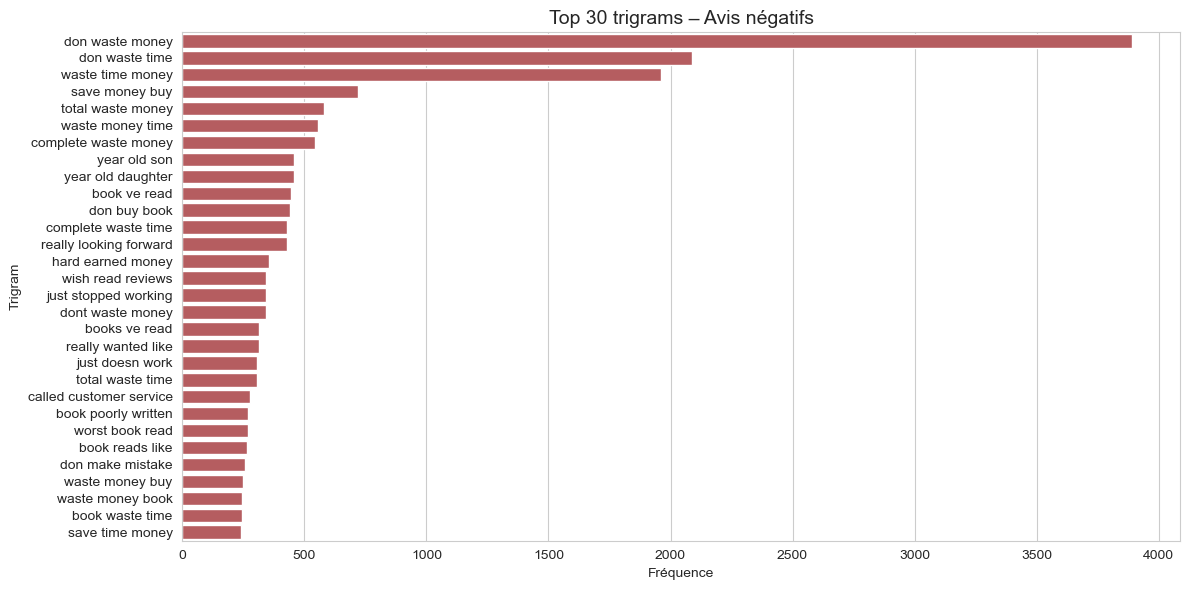

In [33]:
# Trigrams 

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

sns.set_style("whitegrid")

def get_top_trigrams(texts, title, color):
    # Vectorisation trigrams
    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=(3, 3),
        max_features=30
    )
    X = vectorizer.fit_transform(texts)
    trigrams = vectorizer.get_feature_names_out()
    counts = X.sum(axis=0).A1  # fréquences

    df = pd.DataFrame({"trigram": trigrams, "count": counts})
    df = df.sort_values("count", ascending=False)

    # Plot horizontal
    plt.figure(figsize=(12,6))
    sns.barplot(
        data=df,
        x="count",
        y="trigram",
        palette=[color] * len(df)
    )
    plt.title(title, fontsize=14)
    plt.xlabel("Fréquence")
    plt.ylabel("Trigram")
    plt.tight_layout()
    plt.show()

    return df


# === Global ===
trigrams_global_df = get_top_trigrams(
    sample["clean_text"],
    "Top 30 trigrams – Corpus global",
    "#4C72B0"
)

# === Positifs ===
trigrams_pos_df = get_top_trigrams(
    sample[sample["sentiment"]=="positive"]["clean_text"],
    "Top 30 trigrams – Avis positifs",
    "#55A868"
)

# === Négatifs ===
trigrams_neg_df = get_top_trigrams(
    sample[sample["sentiment"]=="negative"]["clean_text"],
    "Top 30 trigrams – Avis négatifs",
    "#C44E52"
)

6.5	Analyse des stopwords

* Extraction des stopwords les plus fréquents

* Analyse des stopwords spécifiques au corpus

* Décision métier + technique : faut-il les supprimer dans la modélisation ?

In [116]:
# Combien de fois chaque stopword apparaît dans clean_text

from nltk.corpus import stopwords
from collections import Counter

stopwords_eng = set(stopwords.words("english"))

def get_stopword_frequencies(texts, stopwords_list, n=20):
    counter = Counter()
    for text in texts:
        for word in text.split():
            if word in stopwords_list:
                counter[word] += 1
    return counter.most_common(n)

top_stopwords = get_stopword_frequencies(sample["clean_text"], stopwords_eng)
#pd.DataFrame(top_stopwords, columns=["stopword", "count"])

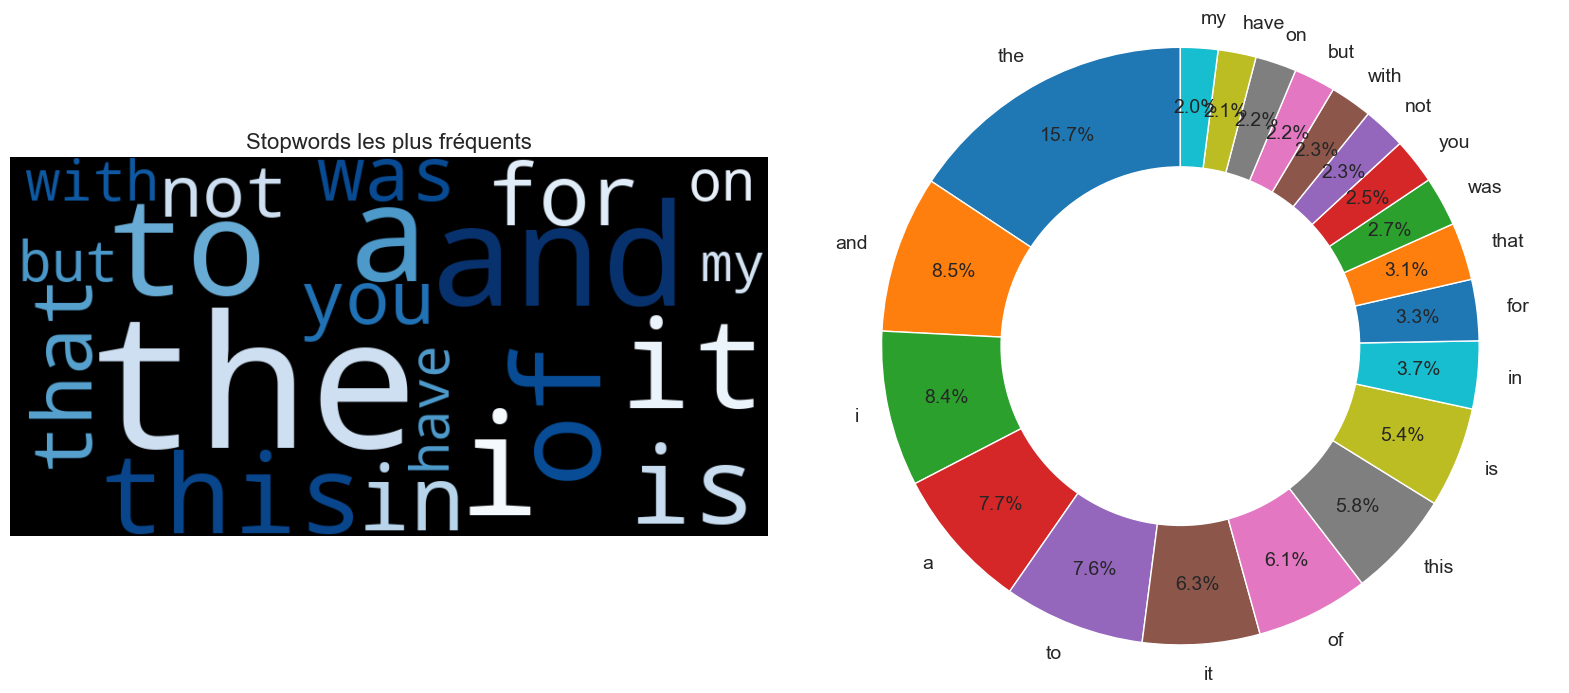

In [118]:
# Conversion des stopwords en dict pour le wordcloud
sw_dict = {w: c for w, c in top_stopwords}

# Données pour le donut chart
df_sw = pd.DataFrame(top_stopwords, columns=["stopword", "count"])

# --- Création de la figure ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ----------------- SUBPLOT 1 : WORDCLOUD -----------------
wc_sw = WordCloud(
    width=800,
    height=400,
    background_color="black",
    colormap="Blues"
).generate_from_frequencies(sw_dict)

axes[0].imshow(wc_sw, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Stopwords les plus fréquents", fontsize=16)

# ----------------- SUBPLOT 2 : DONUT CHART -----------------
wedges, texts, autotexts = axes[1].pie(
    df_sw["count"],
    labels=df_sw["stopword"],
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.80
)

# Agrandir la taille des labels (stopwords)
for txt in texts:
    txt.set_fontsize(14)

# Agrandir la taille des valeurs en pourcentage
for autotxt in autotexts:
    autotxt.set_fontsize(14)

# Cercle blanc au centre
centre_circle = plt.Circle((0, 0), 0.60, color='white', fc='white')
axes[1].add_artist(centre_circle)
axes[1].axis("equal")

# ----------------- AFFICHAGE FINAL -----------------
plt.tight_layout()
plt.show()

In [131]:
from nltk.corpus import stopwords
from collections import Counter

stopwords_eng = set(stopwords.words("english"))

def get_stopword_frequencies(texts, stopwords_list, n=20):
    counter = Counter()
    for text in texts:
        for word in text.split():
            if word in stopwords_list:
                counter[word] += 1
    return counter.most_common(n)

# Échantillon pour éviter les lenteurs
sample = train.sample(200000, random_state=42)

# Séparation pos/neg
sample_pos = sample[sample["sentiment"] == "positive"]
sample_neg = sample[sample["sentiment"] == "negative"]

# Top stopwords
top_sw_pos = get_stopword_frequencies(sample_pos["clean_text"], stopwords_eng)
top_sw_neg = get_stopword_frequencies(sample_neg["clean_text"], stopwords_eng)

In [132]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd

def plot_sw_wordcloud_and_donut(top_sw, title_cloud, title_donut, cmap="Blues"):
    
    sw_dict = {w: c for w, c in top_sw}
    df_sw = pd.DataFrame(top_sw, columns=["stopword", "count"])

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # --- Wordcloud ---
    wc_sw = WordCloud(
        width=800,
        height=400,
        background_color="black",
        colormap=cmap
    ).generate_from_frequencies(sw_dict)

    axes[0].imshow(wc_sw, interpolation="bilinear")
    axes[0].axis("off")
    axes[0].set_title(title_cloud, fontsize=16)

    # --- Donut Chart ---
    wedges, texts, autotexts = axes[1].pie(
        df_sw["count"],
        labels=df_sw["stopword"],
        autopct="%1.1f%%",
        startangle=90,
        pctdistance=0.80
    )

    # style des labels
    for txt in texts:
        txt.set_fontsize(14)
    for autotxt in autotexts:
        autotxt.set_fontsize(14)

    # cercle central
    centre_circle = plt.Circle((0, 0), 0.60, color="white")
    axes[1].add_artist(centre_circle)
    axes[1].axis("equal")
    axes[1].set_title(title_donut, fontsize=16)

    plt.tight_layout()
    plt.show()

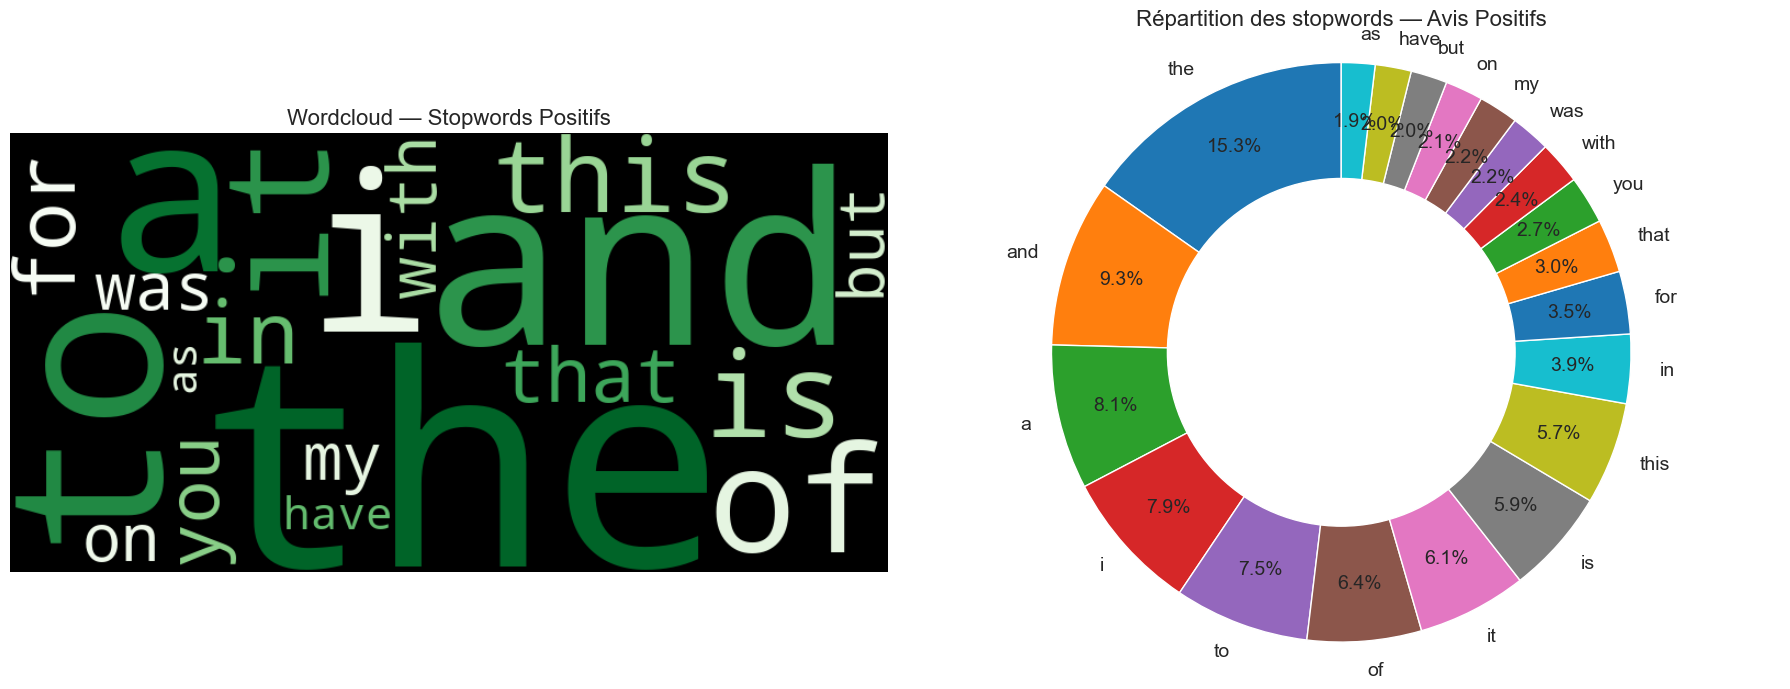

In [134]:
# Stopwords POSITIFS
plot_sw_wordcloud_and_donut(
    top_sw_pos,
    "Wordcloud — Stopwords Positifs",
    "Répartition des stopwords — Avis Positifs",
    cmap="Greens")

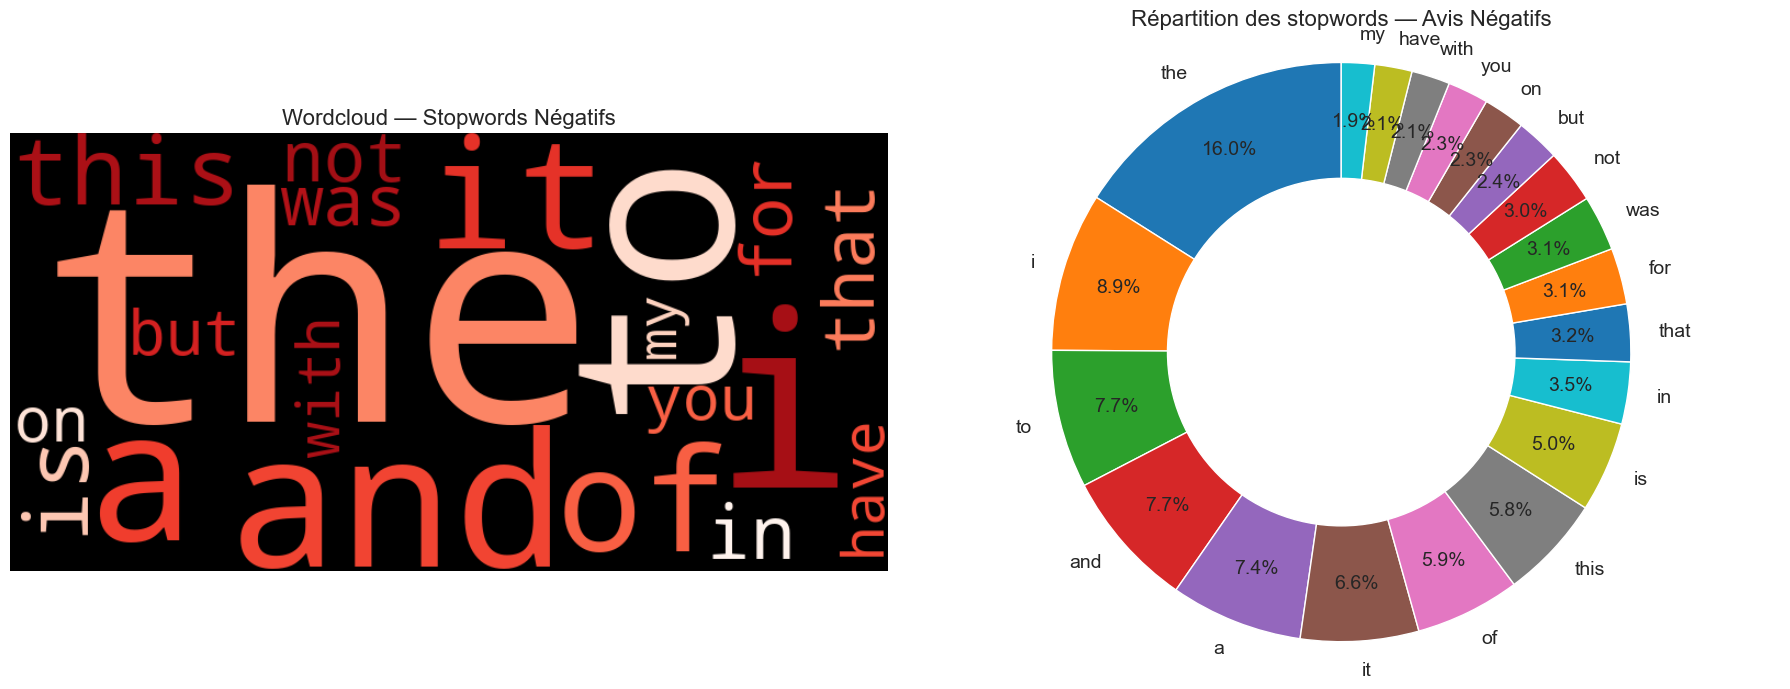

In [135]:
# Stopwords NÉGATIFS
plot_sw_wordcloud_and_donut(
    top_sw_neg,
    "Wordcloud — Stopwords Négatifs",
    "Répartition des stopwords — Avis Négatifs",
    cmap="Reds"
)